In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.datab import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [3]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

from scripts.datab import engine
import pandas as pd

QUERY = """
SELECT
    p.titulo AS pelicula,
    p.anio,
    p.genero,
    p.director,

    r.imdb_rating,
    r.duracion_minutos,
    r.recaudacion,
    r.fecha_extraccion

FROM registro_peliculas r
JOIN peliculas p ON r.pelicula_id = p.id
ORDER BY r.fecha_extraccion;
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 1,010
   Columnas : 8

📋 Primeras filas:


,pelicula,anio,genero,director,imdb_rating,duracion_minutos,recaudacion,fecha_extraccion
0,Inception,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,8.3,130,765029346,2026-01-05 03:55:47
1,Pulp Fiction,1994,"Crime, Drama",Quentin Tarantino,8.6,141,470511502,2026-01-05 03:55:47
2,Interstellar,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,8.5,146,439114647,2026-01-05 03:55:47
3,The Shawshank Redemption,1994,Drama,Frank Darabont,8.6,124,650090239,2026-01-05 03:55:47
4,The Godfather,1972,"Crime, Drama",Francis Ford Coppola,9.0,116,672765603,2026-01-05 03:55:47


In [4]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET (PELÍCULAS)")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🎬 Películas en el dataset:")
print(df['pelicula'].value_counts())

print("\n🎭 Géneros más frecuentes:")
print(df['genero'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET (PELÍCULAS)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   pelicula          1010 non-null   object        
 1   anio              1010 non-null   int64         
 2   genero            1010 non-null   object        
 3   director          1010 non-null   object        
 4   imdb_rating       1010 non-null   float64       
 5   duracion_minutos  1010 non-null   int64         
 6   recaudacion       1010 non-null   int64         
 7   fecha_extraccion  1010 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 63.3+ KB
None

📊 Valores nulos por columna:
pelicula            0
anio                0
genero              0
director            0
imdb_rating         0
duracion_minutos    0
recaudacion         0
fecha_extraccion    0
dtype: int64

🎬

In [5]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = ['imdb_rating', 'duracion_minutos', 'recaudacion']

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS (PELÍCULAS)")
print("=" * 50)
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS (PELÍCULAS)
       imdb_rating  duracion_minutos   recaudacion
count      1010.00           1010.00  1.010000e+03
mean          8.50            139.22  4.908758e+08
std           0.31             15.08  2.018351e+08
min           7.60             90.00  2.876719e+07
25%           8.30            130.00  3.496396e+08
50%           8.50            140.00  5.006102e+08
75%           8.70            149.00  6.288807e+08
max           9.50            194.00  1.082849e+09


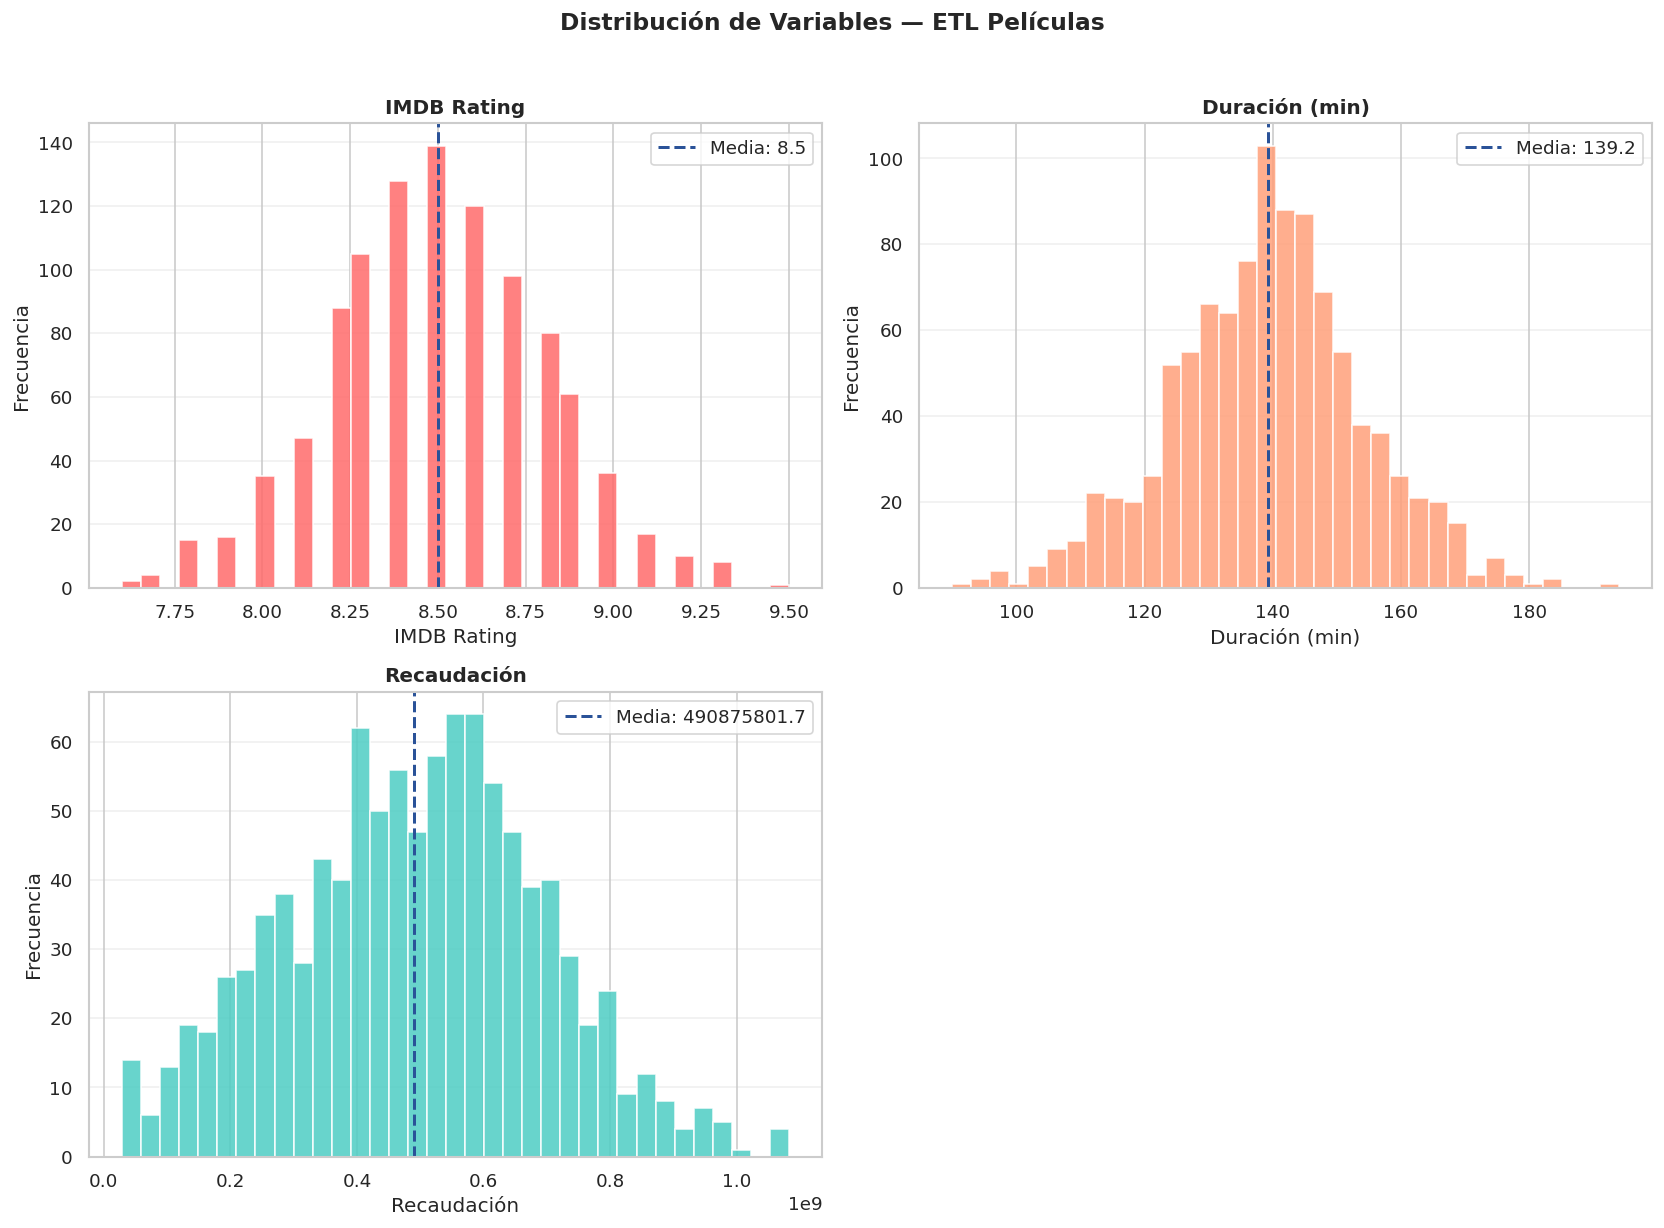

In [6]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

import matplotlib.pyplot as plt
import os

os.makedirs("../data/graficas", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables — ETL Películas',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'imdb_rating':       ('IMDB Rating',         '#ff6b6b'),
    'duracion_minutos':  ('Duración (min)',      '#ffa07a'),
    'recaudacion':       ('Recaudación',         '#4ecdc4'),
}

axes = axes.flatten()

for i, (col, (label, color)) in enumerate(datos.items()):
    ax = axes[i]
    
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)

    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Ocultar subplot vacío (porque tienes 3 variables y 4 espacios)
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones_peliculas.png',
            dpi=150, bbox_inches='tight')

plt.show()

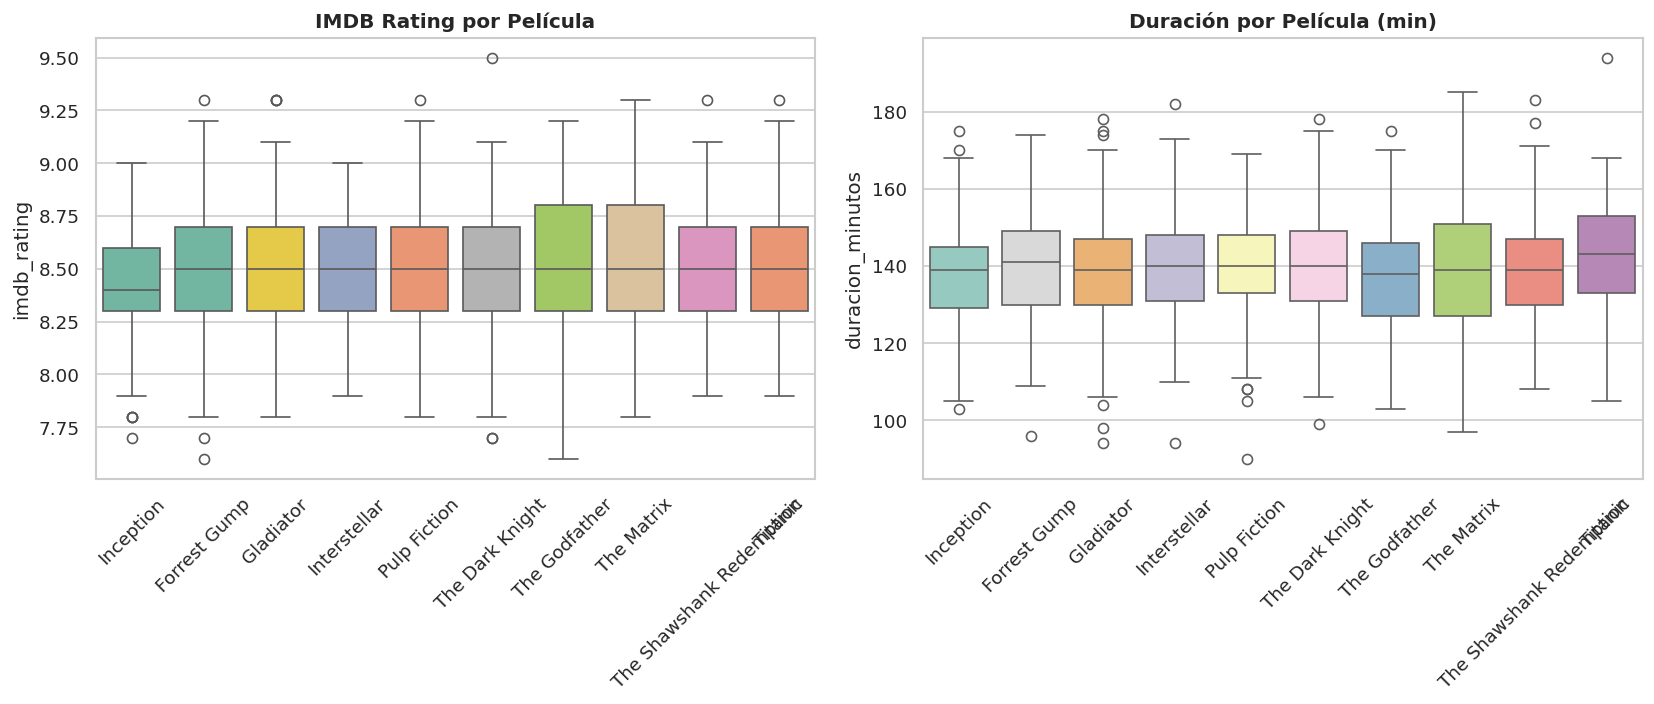

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.dropna(subset=['pelicula', 'imdb_rating'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('pelicula')['imdb_rating'].median().sort_values().index

# ── IMDB Rating ─────────────────────────────
sns.boxplot(
    data=df,
    x='pelicula',
    y='imdb_rating',
    hue='pelicula',        # 👈 clave
    order=orden,
    palette='Set2',
    ax=axes[0],
    legend=False           # 👈 evita duplicar leyenda
)

axes[0].set_title('IMDB Rating por Película', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# ── Duración ─────────────────────────────
sns.boxplot(
    data=df,
    x='pelicula',
    y='duracion_minutos',
    hue='pelicula',        # 👈 clave
    order=orden,
    palette='Set3',
    ax=axes[1],
    legend=False
)

axes[1].set_title('Duración por Película (min)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

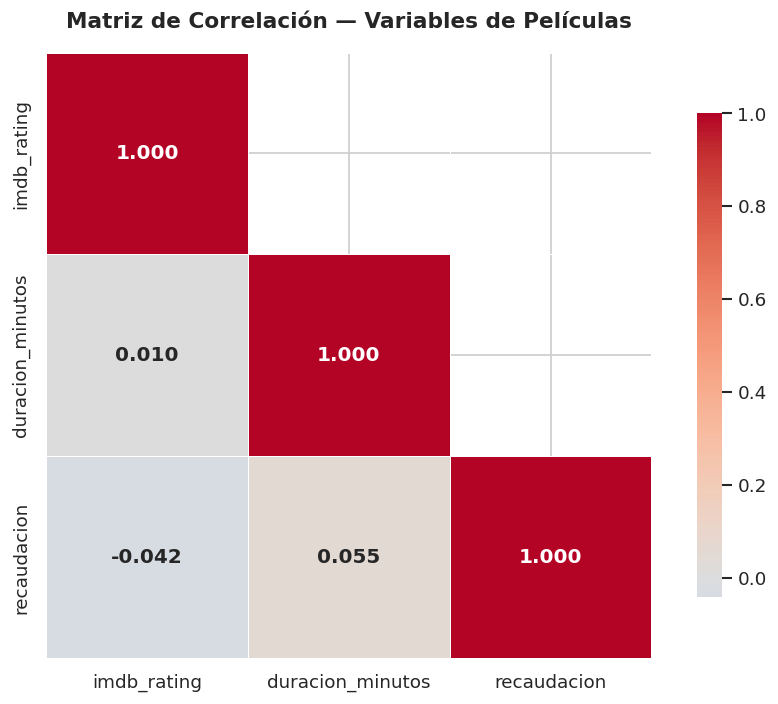

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas del ETL de películas
vars_num = ['imdb_rating', 'duracion_minutos', 'recaudacion']

corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # triángulo superior

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 12, 'weight': 'bold'}
)

plt.title(
    'Matriz de Correlación — Variables de Películas',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion_peliculas.png',
            dpi=150, bbox_inches='tight')

plt.show()

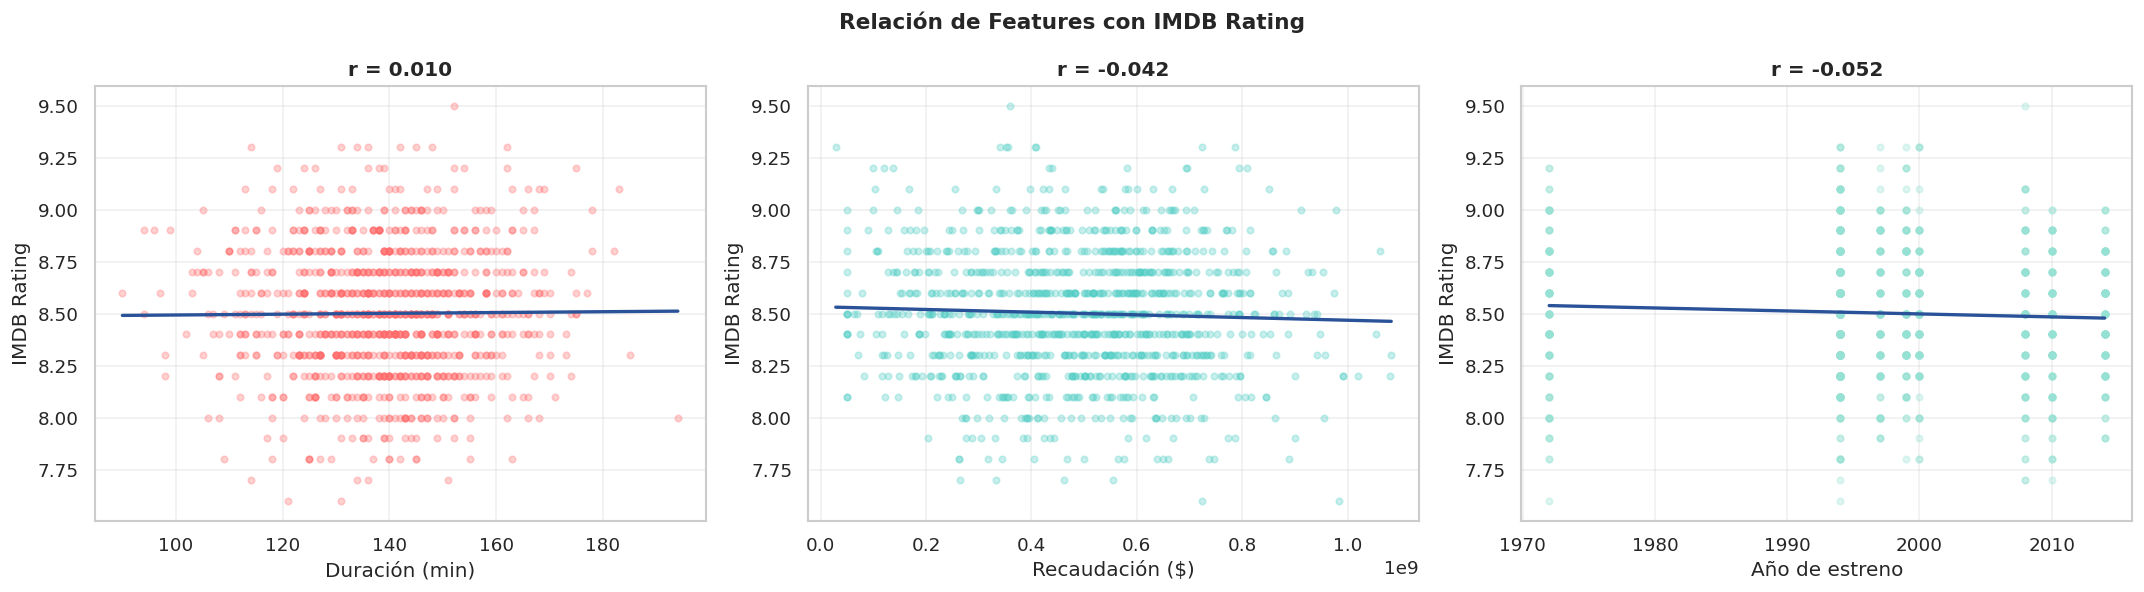

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Relación de Features con IMDB Rating',
             fontsize=13, fontweight='bold')

pares = [
    ('duracion_minutos', 'Duración (min)', '#ff6b6b'),
    ('recaudacion', 'Recaudación ($)', '#4ecdc4'),
    ('anio', 'Año de estreno', '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    
    # limpieza de nulos
    x = df[feature]
    y = df['imdb_rating']
    
    ax.scatter(x, y, alpha=0.3, s=15, color=color)

    # ── línea de tendencia ──
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xp = np.linspace(x.min(), x.max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

    # correlación
    r = df[[feature, 'imdb_rating']].corr().iloc[0, 1]

    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('IMDB Rating')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ───────────────────────────────────────────────
# CELDA 9: Preparación de datos (Train / Test)
# ETL PELÍCULAS - MODELO SIMPLE
# ───────────────────────────────────────────────

from sklearn.model_selection import train_test_split

# 🔹 Eliminar nulos por seguridad
df_model = df.dropna(subset=['duracion_minutos', 'recaudacion', 'imdb_rating'])

# 🔹 Features (X)
X_simple = df_model[['duracion_minutos', 'recaudacion']].values

# 🔹 Target (y)
y = df_model['imdb_rating'].values

# ───────────────────────────────────────────────
# 🔹 División Train / Test
# ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

# ───────────────────────────────────────────────
# 🔹 Resultados
# ───────────────────────────────────────────────
print("📊 DIVISIÓN DEL DATASET")
print("=" * 40)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

print("\n🎬 Features usadas:")
print("- Duración (minutos)")
print("- Recaudación")
print("\n🎯 Target:")
print("- IMDB Rating")

📊 DIVISIÓN DEL DATASET
Train: 808 muestras (80%)
Test : 202 muestras (20%)

🎬 Features usadas:
- Duración (minutos)
- Recaudación

🎯 Target:
- IMDB Rating


In [15]:
from sklearn.linear_model import LinearRegression

# ── Modelo ───────────────────────────────────────────────
modelo_simple = LinearRegression()

# ── Entrenamiento ───────────────────────────────────────
modelo_simple.fit(X_train, y_train)

# ── Predicciones ────────────────────────────────────────
y_pred_simple = modelo_simple.predict(X_test)

# ── Resultados del modelo ───────────────────────────────
print("🤖 MODELO DE REGRESIÓN LINEAL - PELÍCULAS")
print("=" * 50)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")

for i, coef in enumerate(modelo_simple.coef_):
    print(f"Coeficiente β{i+1}: {coef:.4f}")

print("\n📊 Ecuación del modelo:")

print(
    "IMDB Rating = "
    f"{modelo_simple.intercept_:.3f}"
    + " + "
    + " + ".join([
        f"{modelo_simple.coef_[i]:.3f} × X{i+1}"
        for i in range(len(modelo_simple.coef_))
    ])
)

🤖 MODELO DE REGRESIÓN LINEAL - PELÍCULAS
Intercepto  β₀ : 8.5552
Coeficiente β1: -0.0003
Coeficiente β2: -0.0000

📊 Ecuación del modelo:
IMDB Rating = 8.555 + -0.000 × X1 + -0.000 × X2


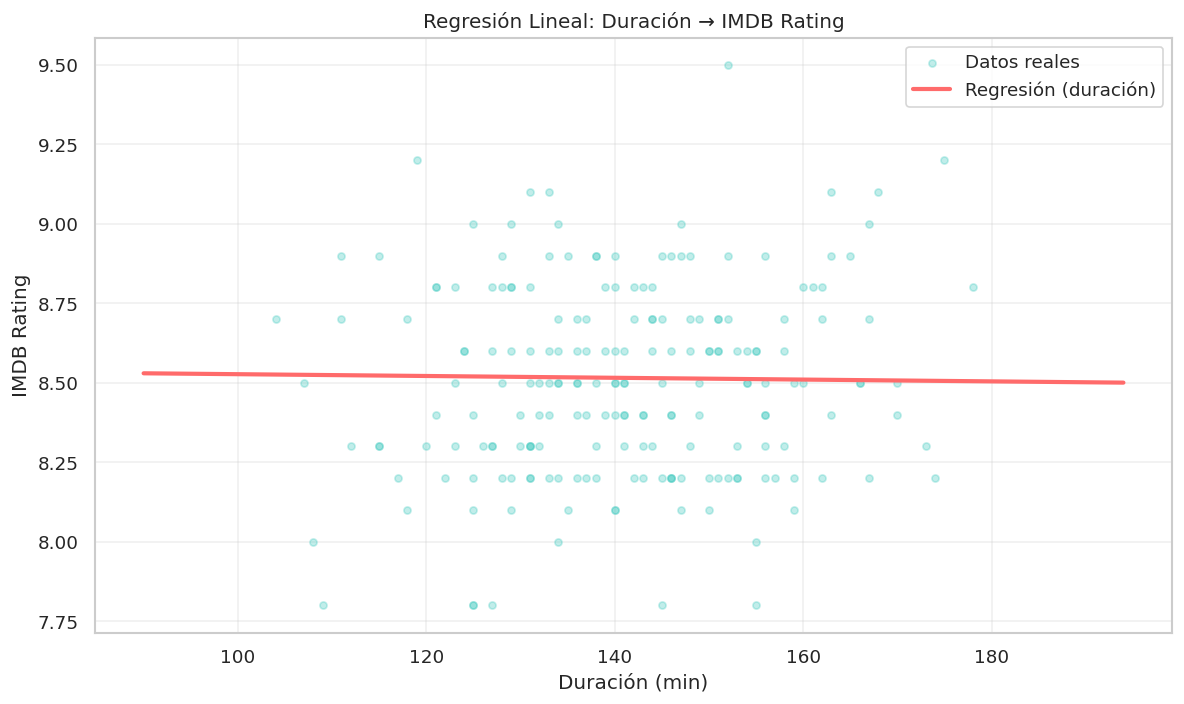

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Solo usamos duración para visualización
ax.scatter(X_test[:, 0], y_test,
           alpha=0.35, s=18,
           color='#4ecdc4', label='Datos reales')

x_line = np.linspace(X_simple[:, 0].min(),
                     X_simple[:, 0].max(), 300).reshape(-1, 2)

# solo usamos primera variable para graficar
x_plot = np.linspace(df['duracion_minutos'].min(),
                     df['duracion_minutos'].max(), 300)

ax.plot(x_plot,
        modelo_simple.intercept_ + modelo_simple.coef_[0] * x_plot,
        color='#ff6b6b', linewidth=2.5,
        label='Regresión (duración)')

ax.set_xlabel('Duración (min)')
ax.set_ylabel('IMDB Rating')
ax.set_title('Regresión Lineal: Duración → IMDB Rating')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (PELÍCULAS)")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (PELÍCULAS)
  R²   (coef. determinación)  : 0.0015  (0.15%)
  MSE  (error cuadrático med)  : 0.0921
  RMSE (raíz del MSE)          : 0.3035
  MAE  (error absoluto medio)  : 0.2454


In [18]:
X_ols = df[['duracion_minutos', 'recaudacion']]
X_ols = sm.add_constant(X_ols)
y_ols = df['imdb_rating']

modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()
print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9832
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.374
Time:                        06:14:28   Log-Likelihood:                -239.36
No. Observations:                1010   AIC:                             484.7
Df Residuals:                    1007   BIC:                             499.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.4990      0.092  

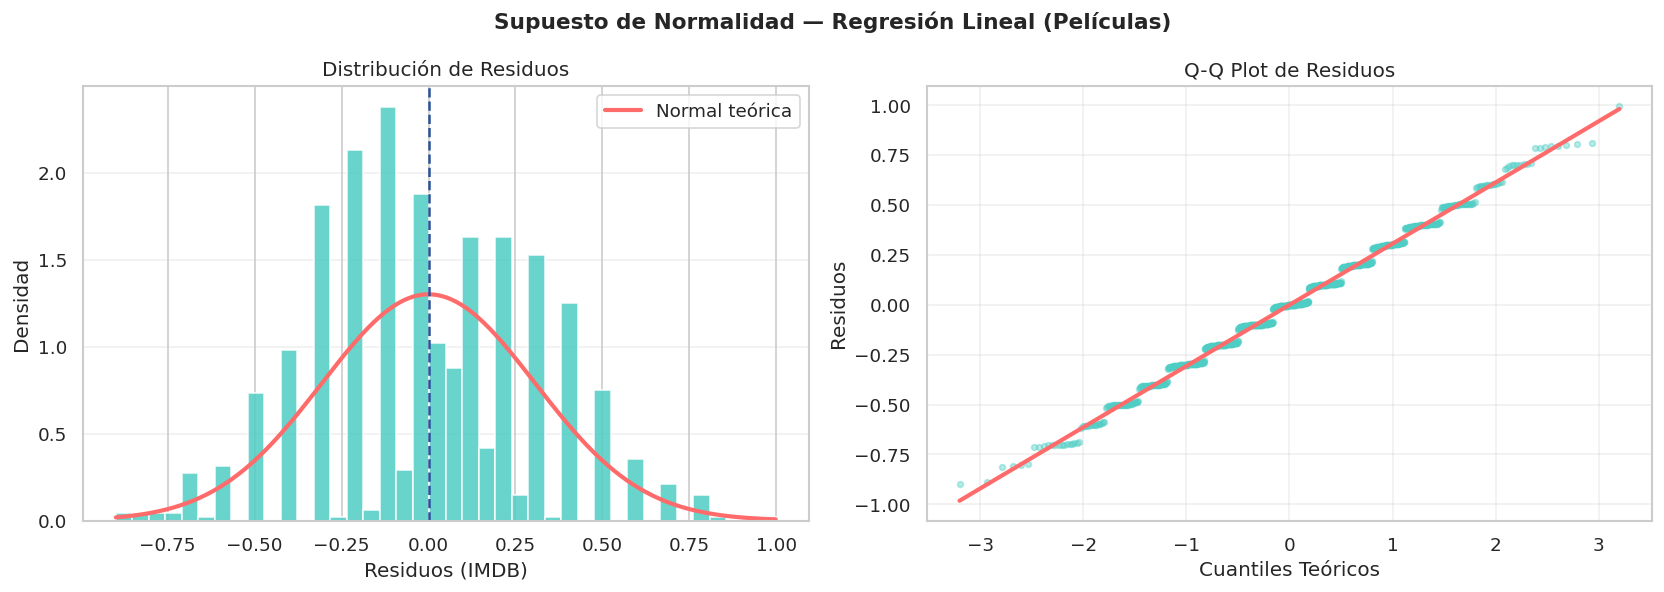


🔬 Test de Shapiro-Wilk (Películas):
   Estadístico W : 0.9942
   p-value       : 0.000568
   Conclusión    : ⚠️ Se rechaza normalidad
   Nota: modelos lineales pueden no ser ideales para este dataset


In [19]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

# Predicción sobre todo el dataset
y_pred_all = modelo_simple.predict(df[['duracion_minutos', 'recaudacion']].values)

# Residuos
residuos = df['imdb_rating'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal (Películas)',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos, bins=40, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuos (IMDB)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4')
axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5
)

axes[1].set_title('Q-Q Plot de Residuos')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk
muestra_sw = (
    residuos if len(residuos) <= 5000
    else np.random.default_rng(42).choice(residuos, 5000, replace=False)
)

stat_sw, p_sw = stats.shapiro(muestra_sw)

print("\n🔬 Test de Shapiro-Wilk (Películas):")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad")
    print("   Nota: modelos lineales pueden no ser ideales para este dataset")

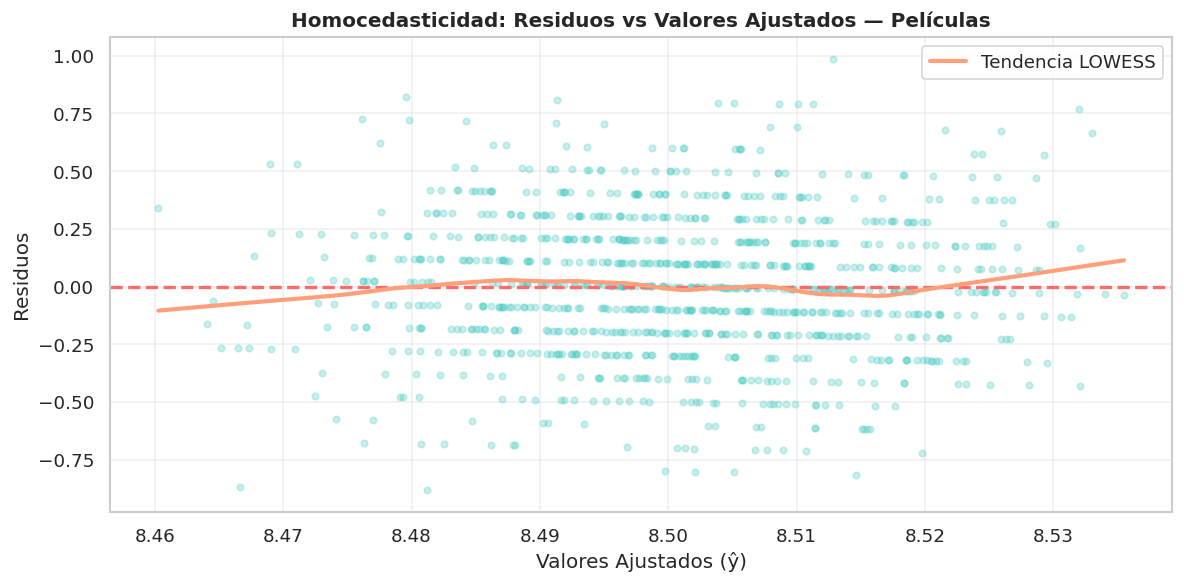


🔬 Test de Breusch-Pagan (Películas):
   Estadístico LM : 0.1436
   p-value        : 0.930697
   Conclusión     : ✅ Homocedasticidad (varianza constante)


In [20]:
# ── CELDA 15: Homocedasticidad (modelo OLS películas) ────────
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt

# Residuos y valores ajustados del modelo OLS
residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))

plt.scatter(
    ajustados_ols,
    residuos_ols,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)

plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# LOWESS smoothing
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)

plt.plot(
    lowess[:, 0],
    lowess[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='Tendencia LOWESS'
)

plt.xlabel('Valores Ajustados (ŷ)')
plt.ylabel('Residuos')
plt.title('Homocedasticidad: Residuos vs Valores Ajustados — Películas',
          fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homocedasticidad_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Películas):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (varianza constante)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada")

In [21]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features del modelo (puedes ajustar según tu dataset)
FEATURES = ['duracion_minutos', 'recaudacion']

X_multi = df[FEATURES].values
y = df['imdb_rating'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.4f}")

Intercepto β₀ : 8.5552
Coeficiente   duracion_minutos : -0.0003
Coeficiente        recaudacion : -0.0000


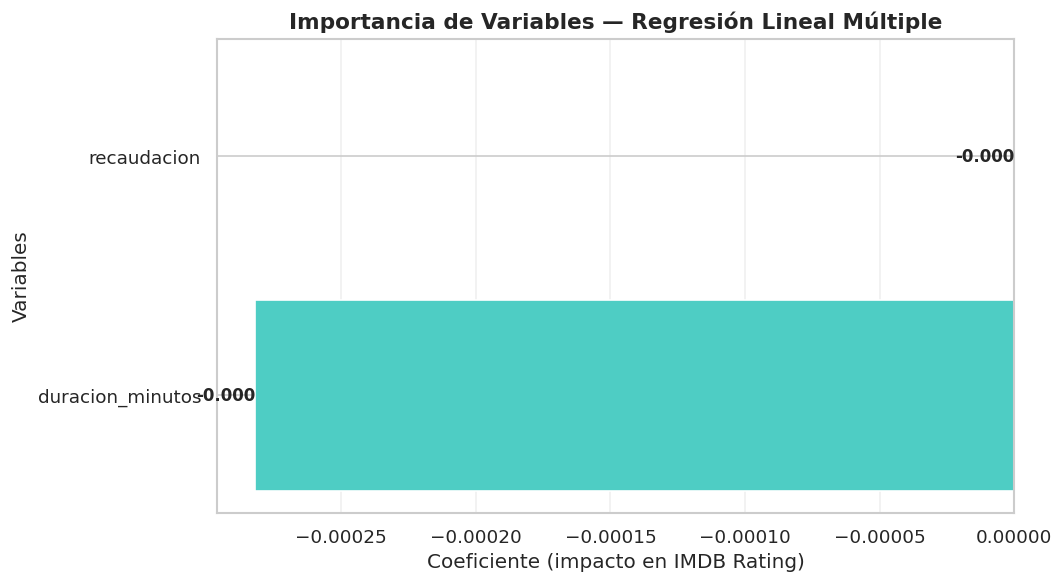

In [24]:
# ── CELDA 17: Coeficientes mejorados ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Ordenar coeficientes por importancia
coef = modelo_multi.coef_
features = np.array(FEATURES)

idx = np.argsort(coef)
coef_sorted = coef[idx]
features_sorted = features[idx]

colores = ['#4ecdc4' if c < 0 else '#ff6b6b' for c in coef_sorted]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    features_sorted,
    coef_sorted,
    color=colores,
    edgecolor='white'
)

ax.axvline(0, color='black', linewidth=1, alpha=0.6)

ax.set_title('Importancia de Variables — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

ax.set_xlabel('Coeficiente (impacto en IMDB Rating)')
ax.set_ylabel('Variables')

# Etiquetas más limpias
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center',
        ha='left' if width > 0 else 'right',
        fontsize=10,
        fontweight='bold'
    )

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/coeficientes_peliculas.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [25]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("\n" + "=" * 55)
print("      📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 55)

print(f"  📈 R²   (coef. determinación) : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  📉 MSE  (error cuadrático)    : {mse_m:.4f}")
print(f"  📊 RMSE (raíz del error)      : {rmse_m:.4f}")
print(f"  📌 MAE  (error absoluto)      : {mae_m:.4f}")

print("=" * 55)

# Interpretación automática
print("\n🧠 INTERPRETACIÓN:")
if r2_m >= 0.8:
    print("  ✅ El modelo tiene un excelente ajuste.")
elif r2_m >= 0.6:
    print("  ⚠️ El modelo tiene un ajuste aceptable.")
else:
    print("  ❌ El modelo tiene bajo ajuste, revisar variables.")


      📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  📈 R²   (coef. determinación) : 0.0015  (0.15%)
  📉 MSE  (error cuadrático)    : 0.0921
  📊 RMSE (raíz del error)      : 0.3035
  📌 MAE  (error absoluto)      : 0.2454

🧠 INTERPRETACIÓN:
  ❌ El modelo tiene bajo ajuste, revisar variables.


In [27]:
# ── CELDA 19: OLS statsmodels — modelo múltiple (PELÍCULAS) ──
import statsmodels.api as sm

# Features del modelo de películas
FEATURES = ['duracion_minutos', 'recaudacion']

# Matriz X con constante
X_ols_m = sm.add_constant(df[FEATURES])

# Variable objetivo
y = df['imdb_rating']

# Modelo OLS
modelo_ols_multi = sm.OLS(y, X_ols_m).fit()

# ── Resumen del modelo ────────────────────────────────────────
print("\n" + "=" * 70)
print("        🎬 RESUMEN OLS — REGRESIÓN LINEAL MÚLTIPLE")
print("                (IMDB Rating - Películas)")
print("=" * 70)

print(modelo_ols_multi.summary())


        🎬 RESUMEN OLS — REGRESIÓN LINEAL MÚLTIPLE
                (IMDB Rating - Películas)
                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9832
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.374
Time:                        06:24:16   Log-Likelihood:                -239.36
No. Observations:                1010   AIC:                             484.7
Df Residuals:                    1007   BIC:                             499.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [28]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza (PELÍCULAS) ──
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Features del modelo de películas
FEATURES = ['duracion_minutos', 'recaudacion']

# Dataset para VIF (sin NaN)
X_vif = df[FEATURES].dropna().copy()

# Cálculo VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = FEATURES
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(FEATURES))
]

# Redondeo
vif_data["VIF"] = vif_data["VIF"].round(3)

# Interpretación automática
def interpretar_vif(v):
    if v < 5:
        return "✅ Sin multicolinealidad"
    elif v < 10:
        return "⚠️ Moderada"
    else:
        return "❌ Alta multicolinealidad"

vif_data["Criterio"] = vif_data["VIF"].apply(interpretar_vif)

# ── Resultado ────────────────────────────────────────────────
print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 55)
print(vif_data.to_string(index=False))
print("=" * 55)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable   VIF                Criterio
duracion_minutos 6.655             ⚠️ Moderada
     recaudacion 0.182 ✅ Sin multicolinealidad


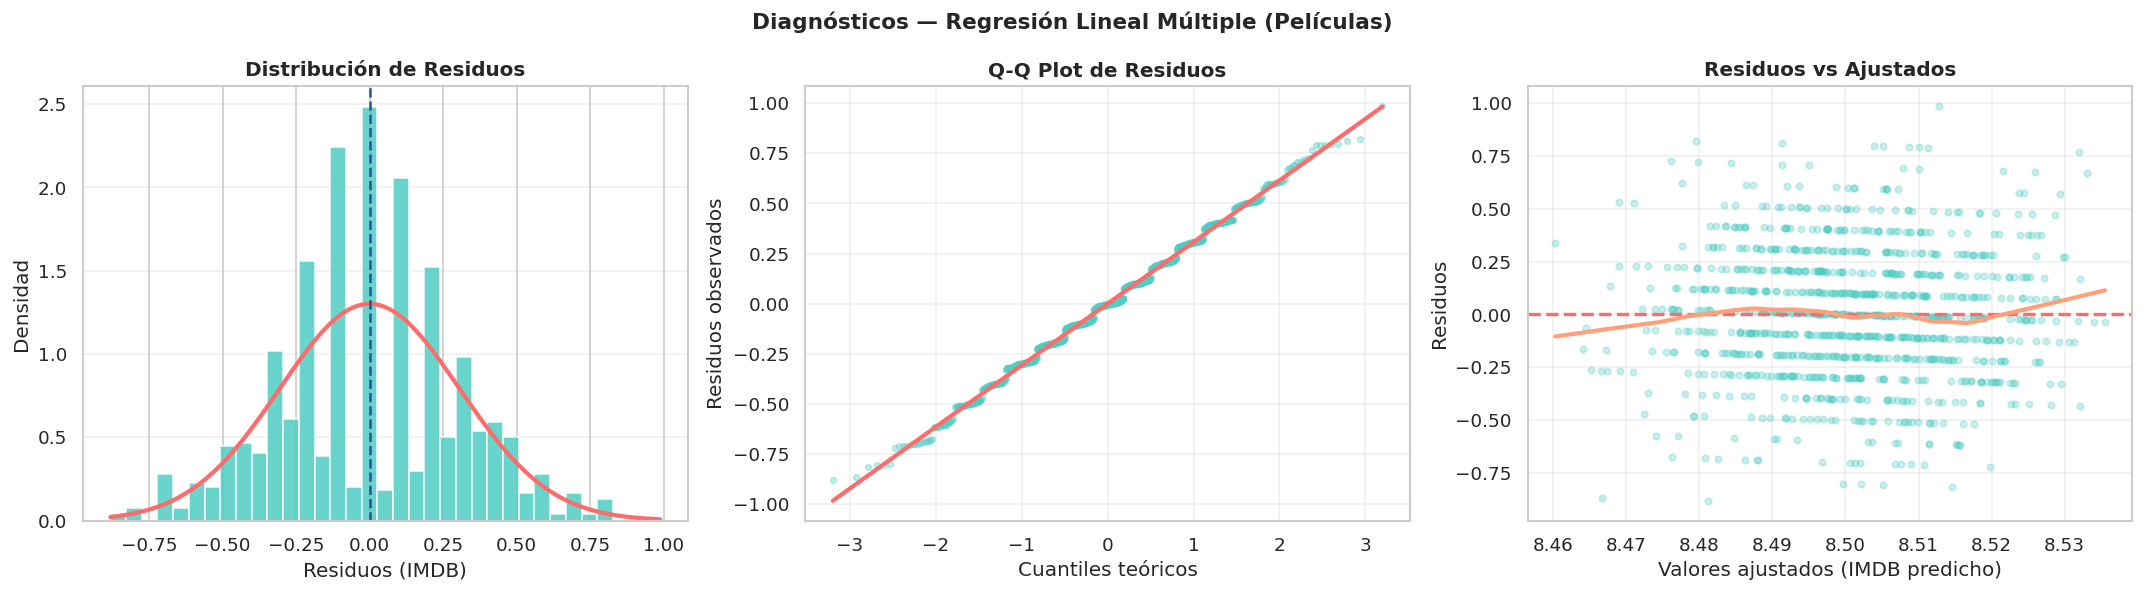


🔬 TESTS ESTADÍSTICOS — MODELO PELÍCULAS
📌 Shapiro-Wilk (normalidad): p = 0.017501
   → ⚠️ No normal

📌 Breusch-Pagan (homocedasticidad): p = 0.930697
   → ✅ Homocedasticidad


In [33]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple (PELÍCULAS) ──
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuos y ajustados del modelo OLS múltiple
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Películas)',
             fontsize=13, fontweight='bold')

# ─────────────────────────────
# 1. Histograma de residuos
axes[0].hist(residuos_m, bins=35, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)

axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (IMDB)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ─────────────────────────────
# 2. Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles teóricos')
axes[1].set_ylabel('Residuos observados')
axes[1].grid(alpha=0.3)

# ─────────────────────────────
# 3. Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m,
                alpha=0.30, s=15, color='#4ecdc4')

axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5)

axes[2].set_title('Residuos vs Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (IMDB predicho)')
axes[2].set_ylabel('Residuos')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────
# Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols_multi.resid,
    modelo_ols_multi.model.exog
)

print("\n🔬 TESTS ESTADÍSTICOS — MODELO PELÍCULAS")
print("=" * 55)

print(f"📌 Shapiro-Wilk (normalidad): p = {p_sw_m:.6f}")
print("   →", "✅ Normalidad aceptada" if p_sw_m > 0.05 else "⚠️ No normal")

print(f"\n📌 Breusch-Pagan (homocedasticidad): p = {lm_p_m:.6f}")
print("   →", "✅ Homocedasticidad" if lm_p_m > 0.05 else "⚠️ Heterocedasticidad")

In [30]:
# ── CELDA 22: Comparación final de modelos (PELÍCULAS) ───────
import pandas as pd

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    
    'Variables': [
        'duracion_minutos',
        'duracion_minutos + recaudacion'
    ],
    
    'R²': [
        round(r2, 4),
        round(r2_m, 4)
    ],
    
    'R² Ajustado': [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    
    'RMSE': [
        round(rmse, 4),
        round(rmse_m, 4)
    ],
    
    'MAE': [
        round(mae, 4),
        round(mae_m, 4)
    ],
    
    'AIC': [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    
    'BIC': [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("\n" + "=" * 80)
print("                📊 COMPARACIÓN FINAL DE MODELOS")
print("=" * 80)

print(comparacion.to_string(index=False))

print("=" * 80)
print("\n🧠 INTERPRETACIÓN:")
print("✔ Menor RMSE/MAE → mejor predicción")
print("✔ Mayor R² → mejor explicación del modelo")
print("✔ Menor AIC/BIC → modelo más eficiente (menos sobreajuste)")


                📊 COMPARACIÓN FINAL DE MODELOS
            Modelo                      Variables     R²  R² Ajustado   RMSE    MAE    AIC    BIC
  Regresión Simple               duracion_minutos 0.0015         -0.0 0.3035 0.2454 484.72 499.47
Regresión Múltiple duracion_minutos + recaudacion 0.0015         -0.0 0.3035 0.2454 484.72 499.47

🧠 INTERPRETACIÓN:
✔ Menor RMSE/MAE → mejor predicción
✔ Mayor R² → mejor explicación del modelo
✔ Menor AIC/BIC → modelo más eficiente (menos sobreajuste)


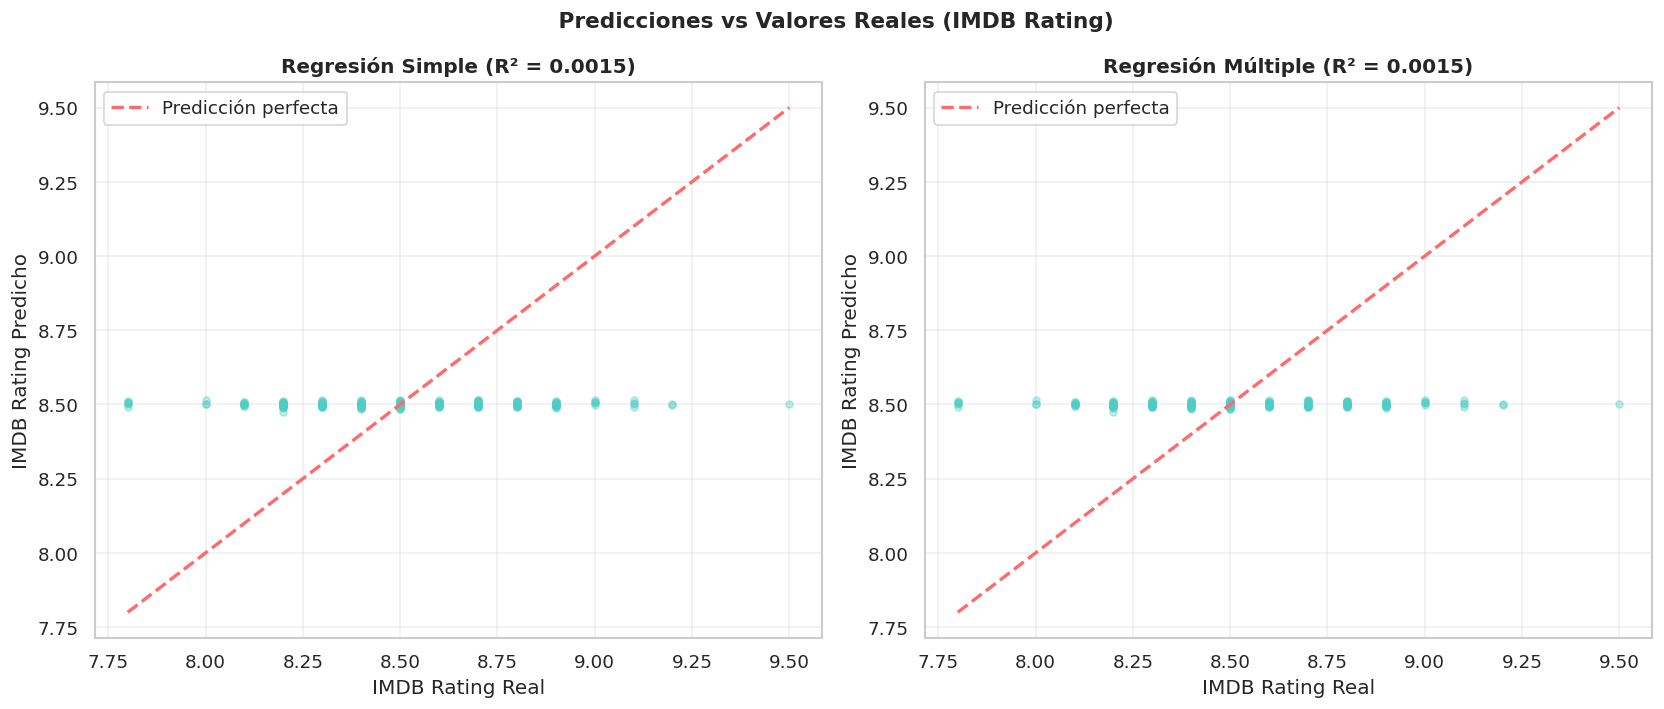

In [32]:
# ── CELDA 23: Predicciones vs Reales — modelos de películas ──
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(' Predicciones vs Valores Reales (IMDB Rating)',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    ax.scatter(y_real, y_pred,
               alpha=0.35, s=18, color='#4ecdc4')

    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linestyle='--', linewidth=2,
            label='Predicción perfecta')

    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})',
                 fontweight='bold')

    ax.set_xlabel('IMDB Rating Real')
    ax.set_ylabel('IMDB Rating Predicho')

    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales_peliculas.png',
            dpi=150, bbox_inches='tight')
plt.show()